# Decision Trees

## Predicting Accidents using Decision Trees


## Goals for the project
1) Create a decision tree model to predict accidents
2) Tune model hyperparameters
3) Explain our model prediction using gini importance

A) Prepare Data: - Import, Explore, Split: Train-validation-test-split
B) Build Model: - Baseline, Iterate:( Decision tree, ordinal encoding, validation curve), Evaluate 
C) Communicate Results: Gini importance

In [71]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from category_encoders import OrdinalEncoder
from data import Repository

import pickle

## Import

In [ ]:
repo = Repository("Road_Safety_Survey_ShortNames.xlsx")
df = repo.wrangle()
df.head()

## Split

### task: Create feature matrix X and target vector y. 

In [11]:
target = "AccOccur"
y=df[target]
X = df.drop(columns=[target, "County"])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)
print("Xtrain values are", X_train.shape)
print("Xtest values are", X_test.shape)
print("ytrain values are", y_train.shape)
print("ytest values are", y_test.shape)

Xtrain values are (811, 19)
Xtest values are (203, 19)
ytrain values are (811,)
ytest values are (203,)


In [16]:
# divide the training data into training and validation sets using randomized train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size = 0.2, random_state = 42
)
print("Xtrain values are", X_train.shape)
print("Xval values are", X_val.shape)
print("ytrain values are", y_train.shape)
print("ytest values are", y_val.shape)

Xtrain values are (648, 19)
Xval values are (163, 19)
ytrain values are (648,)
ytest values are (163,)


# Build Model
## Baseline

In [21]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("The baseline accuracy is: ", round(acc_baseline,2))

The baseline accuracy is:  0.69


## Iterate

In [22]:
# create a pipeline named model that contains an ordinal encoder transformer and a DecisionTreeClassifier predictor.
model = make_pipeline(
    OrdinalEncoder(),
    DecisionTreeClassifier(max_depth=6, random_state=42, class)
)
model.fit(X_train, y_train)

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinalencoder', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,mapping,"[{'col': 'Gender', 'data_type': dtype('O'), 'mapping': Male 1 F...2 dtype: int64}, {'col': 'VehType', 'data_type': dtype('O'), 'mapping': Car ...2 dtype: int64}, ...]"
,cols,"['Gender', 'VehType', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'


In [23]:
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_val = model.score(X_val, y_val)
print("Training Accuracy: ", round(acc_train, 2))
print("Validation Accuracy: ", round(acc_val, 2))

Training Accuracy:  0.78
Validation Accuracy:  0.63


In [25]:
# get the tree depth using get_depth method on the DecisionTreeClassifier in the model
tree_depth = model.named_steps["decisiontreeclassifier"].get_depth()
print("Tree depth: ", tree_depth)

Tree depth:  6


In [ ]:
## create a range of values for max_depth hyperparameter of your models DecisionTreeClassifier.

In [26]:
depth_hyperparams = range(1, 50, 2)
depth_hyperparams

range(1, 50, 2)

In [34]:
# train the model with the max_depth in depth_hyperparams 
training_acc = []
validation_acc = []

for d in depth_hyperparams:
    # build the model
    test_model = make_pipeline(
    OrdinalEncoder(),
    DecisionTreeClassifier(max_depth=6, random_state=42)
    )
    # fit the model
    test_model.fit(X_train, y_train)
    # append the training score
    training_acc.append(test_model.score(X_train, y_train))

    # append the validation score
    validation_acc.append(test_model.score(X_val, y_val))

print("Training Accuracy score:", training_acc[:3])
print("Validation Accuracy scores: ", validation_acc[:3])

Training Accuracy score: [0.7808641975308642, 0.7808641975308642, 0.7808641975308642]
Validation Accuracy scores:  [0.6257668711656442, 0.6257668711656442, 0.6257668711656442]


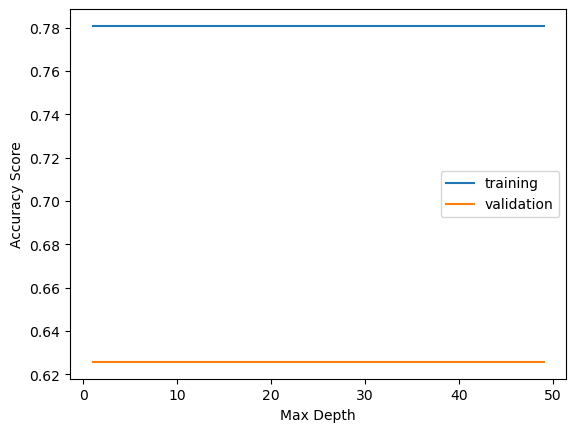

In [30]:
# Plot `depth_hyperparams`, `training_acc`
plt.plot(depth_hyperparams, training_acc, label="training")
plt.plot(depth_hyperparams, validation_acc, label="validation")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy Score")
plt.legend();

In [37]:
# check the accuracy with the test data
test_acc = model.score(X_test, y_test)
print("the test accuracy: ", round(test_acc, 2))

the test accuracy:  0.64


# Communicate

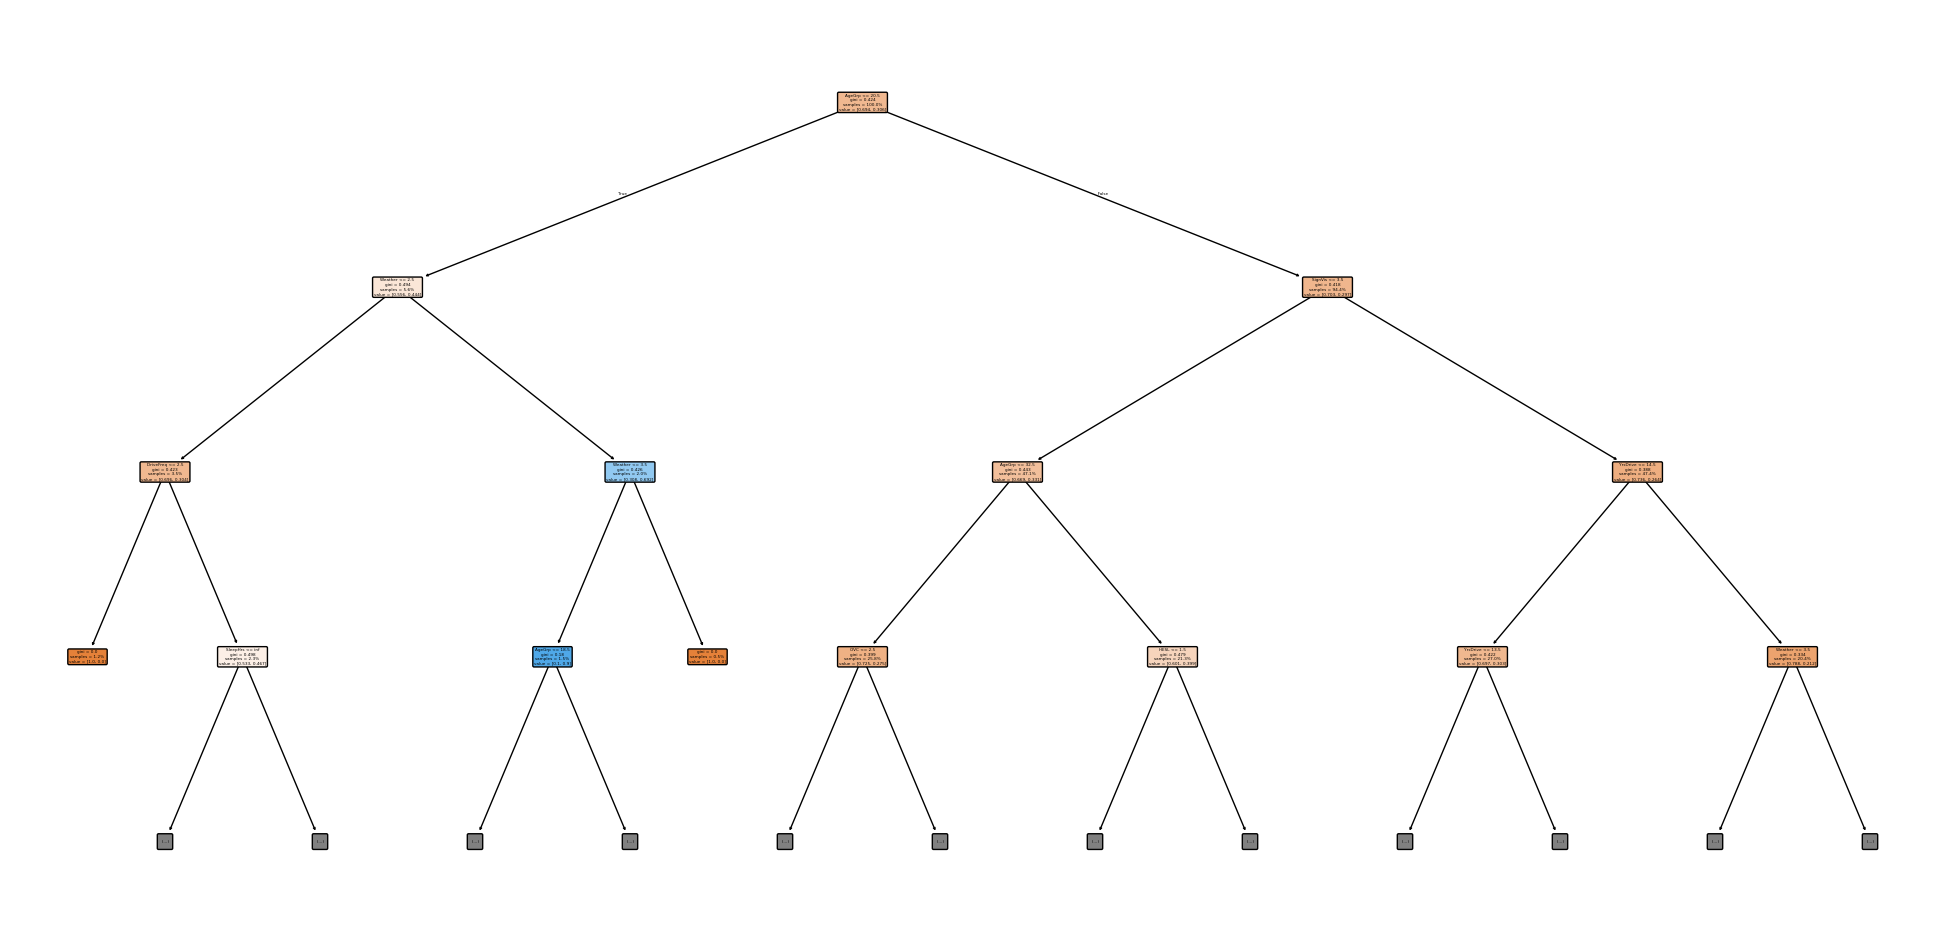

In [40]:
# plot a decision tree using sckit-learn
fig, ax = plt.subplots(figsize=(25, 12))
# plot tree
plot_tree(
    decision_tree = model.named_steps["decisiontreeclassifier"],
    feature_names = X_train.columns.to_list(),
    filled=True,
    rounded=True,
    proportion=True,
    max_depth=3,
    fontsize=3,
    ax=ax,
);

In [41]:
features = X_train.columns
importances = model.named_steps["decisiontreeclassifier"].feature_importances_

print("Features: ", features[:3])
print("Importances: ", importances[:3])

Features:  Index(['AgeGrp', 'Gender', 'YrsDrive'], dtype='object')
Importances:  [0.11122167 0.02727074 0.05506231]


In [42]:
feat_imp = pd.Series(
    importances, index=features
).sort_values()
feat_imp.head()

VehType      0.000000
HPhone       0.000000
Alcohol6h    0.000000
RoadCond     0.000000
DriveEnv     0.012053
dtype: float64

Text(0, 0.5, 'Feature')

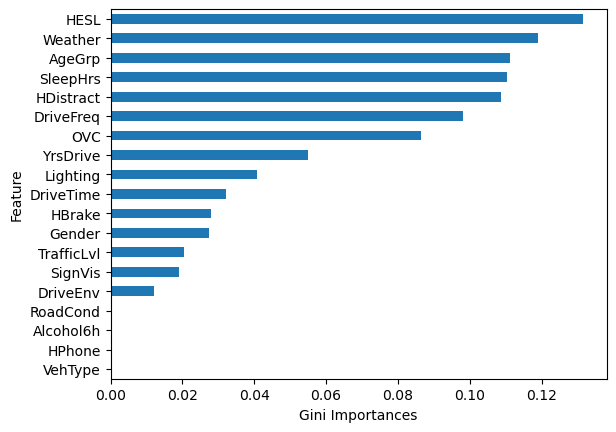

In [43]:
# create a horizontal bar chart with all the features in feat_imp. 
feat_imp.plot(kind="barh")
plt.xlabel("Gini Importances")
plt.ylabel("Feature")